# Does the Largest Community Correspond to a Single Lineage?

**Project:** Comparative Genomic and Network Analysis of Co-occurring Drug-Resistance Mutations Across African *M. tuberculosis* Lineages

**Purpose:** The Objective 3 report flagged the pooled network's largest
Louvain community (31 nodes, inside the giant component) as a natural
candidate for closer inspection once lineage data was available: does it
correspond to a single lineage (another instance of the population-
structure confound Objective 2 and Objective 4 already found operating
elsewhere), or does it span multiple lineages (which would be evidence of
a real, lineage-independent group of co-transmitted mutations)? This
notebook answers that question directly against the real data.

**Why a notebook, not a script:** this is a one-off analytical check
answering a specific question raised in a report, not a deterministic
pipeline stage that other steps depend on — it belongs alongside
`objective3_visualization.ipynb` as exploratory follow-up work, not in
`scripts/`.

**Inputs:** `results/objective3/network_nodes.csv` (Objective 3, for
community membership) and `results/objective1/core_variants_with_mutation_id.csv`
(Objective 1, for per-sample mutation carriage and lineage).

**Method:** a single-mutation view of "who carries a community mutation"
can look diverse even when the community's actual internal structure --
the co-occurrence edges that made Louvain group these nodes together in
the first place -- is concentrated in one lineage. This notebook checks
both: the lineage mix among any carrier of any community mutation, and,
separately, the lineage mix among samples carrying several community
mutations *together*, which is the population that actually generates
the community's defining internal edges.

In [1]:
# ---- CONFIG ----
OBJ1_DIR = "../results/objective1"
OBJ3_DIR = "../results/objective3"
COMMUNITY_ID = None  # None = auto-select the largest community; set an integer to check a specific one instead
# -----------------

import pandas as pd
import matplotlib.pyplot as plt

nodes = pd.read_csv(f"{OBJ3_DIR}/network_nodes.csv")
core = pd.read_csv(f"{OBJ1_DIR}/core_variants_with_mutation_id.csv")

community_sizes = nodes["louvain_community_id"].value_counts().sort_index()
print("Community sizes:")
print(community_sizes)

if COMMUNITY_ID is None:
    COMMUNITY_ID = community_sizes.idxmax()
print(f"\nChecking community {COMMUNITY_ID} (n={community_sizes[COMMUNITY_ID]})")

Community sizes:
louvain_community_id
0      9
1     16
2     13
3      6
4     31
5     19
6      2
7      3
8      9
9      3
10     2
11     2
12     2
13     3
14     2
15     2
16     2
17     2
18     2
Name: count, dtype: int64

Checking community 4 (n=31)


## 1. The Community's Mutations

In [2]:
community = nodes[nodes["louvain_community_id"] == COMMUNITY_ID].copy()
community["mutation_id"] = community["gene"] + "|" + community["change"]
community_mids = set(community["mutation_id"])

print(f"{len(community_mids)} mutations in this community:")
print(community[["gene", "change", "drugs", "degree"]].sort_values("degree", ascending=False).to_string(index=False))

31 mutations in this community:
 gene         change                     drugs  degree
 rpsL     p.Lys43Arg              streptomycin      23
 rpoB    p.Ile491Phe    rifampicin;rifapentine      11
 embB    p.Gly406Ala                ethambutol       9
 pncA    p.Leu151Ser              pyrazinamide       9
 gyrA     p.Asp94Asn levofloxacin;moxifloxacin       8
 pncA    p.Ser104Arg              pyrazinamide       7
 pncA     p.Tyr34Asp              pyrazinamide       6
 gyrA     p.Asp94Ala levofloxacin;moxifloxacin       6
 pncA    p.Gly132Ala              pyrazinamide       6
 pncA     p.His51Asp              pyrazinamide       5
 pncA     p.Ser59Pro              pyrazinamide       5
mmpR5    p.Met146Thr   bedaquiline;clofazimine       4
 pncA       c.-11A>G              pyrazinamide       4
 embB    p.Met306Leu                ethambutol       4
 ethA      c.672dupG ethionamide;prothionamide       4
mmpR5      c.165delA   bedaquiline;clofazimine       4
 rpoB    p.Asn437Ser    rifampici

## 2. Level 1 -- Lineage Mix Among Any Carrier of Any Community Mutation

This is the naive, single-mutation view: pool every sample that carries
at least one of the community's mutations, regardless of how many, and
look at the lineage breakdown.

In [3]:
comm_variants = core[core["mutation_id"].isin(community_mids)]
matched = comm_variants["mutation_id"].nunique()
print(f"Community mutations found in core_variants_with_mutation_id.csv: {matched} / {len(community_mids)}")

any_carriers = comm_variants[["sample_id", "main_lineage"]].drop_duplicates()
print(f"\nTotal distinct carrier samples: {len(any_carriers)}")
print(any_carriers["main_lineage"].value_counts())
print()
print("As a percentage:")
print((any_carriers["main_lineage"].value_counts(normalize=True) * 100).round(1))

Community mutations found in core_variants_with_mutation_id.csv: 31 / 31

Total distinct carrier samples: 263
main_lineage
lineage4             199
lineage2              54
lineage3               4
Unknown                3
lineage1               2
lineage2;lineage4      1
Name: count, dtype: int64

As a percentage:
main_lineage
lineage4             75.7
lineage2             20.5
lineage3              1.5
Unknown               1.1
lineage1              0.8
lineage2;lineage4     0.4
Name: proportion, dtype: float64


## 3. Level 2 -- Lineage Mix Among Samples Carrying Several Community Mutations Together

A single-mutation carrier is, by construction, not contributing to any
*internal* edge of this community on its own -- it takes at least two
community mutations in the same sample for that sample to be part of
what actually makes this a densely-connected group rather than 31
unrelated nodes. This section checks whether lineage concentration rises
as mutation load per sample rises, which would indicate the community's
real internal cohesion is more lineage-concentrated than the diffuse,
any-carrier view alone suggests.

In [4]:
load_per_sample = comm_variants.groupby("sample_id").agg(
    n_community_mutations=("mutation_id", "nunique"),
    main_lineage=("main_lineage", "first"),
).reset_index()

print("Distribution of community-mutation load per carrier sample:")
print(load_per_sample["n_community_mutations"].value_counts().sort_index())
print()

thresholds = [1, 2, 3, 4]
rows = []
for t in thresholds:
    subset = load_per_sample[load_per_sample["n_community_mutations"] >= t]
    if len(subset) == 0:
        continue
    pct = (subset["main_lineage"].value_counts(normalize=True) * 100).round(1)
    top_lineage = pct.idxmax()
    rows.append({"min_mutations": t, "n_samples": len(subset), "top_lineage": top_lineage, "top_lineage_pct": pct.max()})
    print(f"--- Samples carrying >= {t} community mutations together (n={len(subset)}) ---")
    print(pct.to_dict())
    print()

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

Distribution of community-mutation load per carrier sample:
n_community_mutations
1    108
2     81
3     57
4     17
Name: count, dtype: int64

--- Samples carrying >= 1 community mutations together (n=263) ---
{'lineage4': 75.7, 'lineage2': 20.5, 'lineage3': 1.5, 'Unknown': 1.1, 'lineage1': 0.8, 'lineage2;lineage4': 0.4}

--- Samples carrying >= 2 community mutations together (n=155) ---
{'lineage4': 89.7, 'lineage2': 9.7, 'lineage2;lineage4': 0.6}

--- Samples carrying >= 3 community mutations together (n=74) ---
{'lineage4': 91.9, 'lineage2': 8.1}

--- Samples carrying >= 4 community mutations together (n=17) ---
{'lineage4': 100.0}

 min_mutations  n_samples top_lineage  top_lineage_pct
             1        263    lineage4             75.7
             2        155    lineage4             89.7
             3         74    lineage4             91.9
             4         17    lineage4            100.0


## 4. Visualizing the Gradient

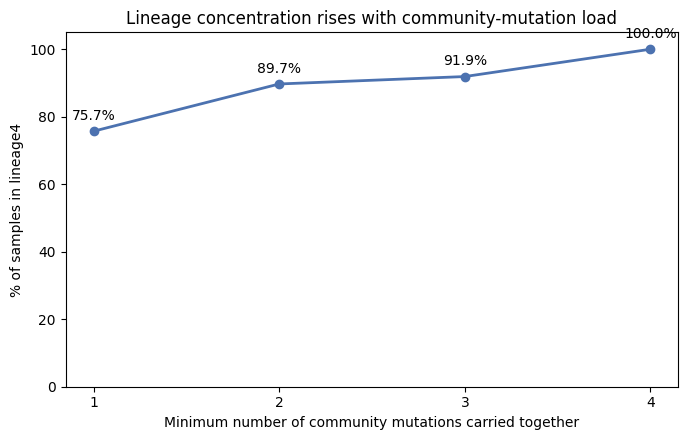

Saved: ../results/objective3_community_check/community_lineage_gradient.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(summary_df["min_mutations"], summary_df["top_lineage_pct"], marker="o", linewidth=2, color="#4C72B0")
ax.set_xlabel("Minimum number of community mutations carried together")
ax.set_ylabel(f"% of samples in {summary_df['top_lineage'].iloc[0]}")
ax.set_title("Lineage concentration rises with community-mutation load")
ax.set_ylim(0, 105)
ax.set_xticks(summary_df["min_mutations"])
for x, y in zip(summary_df["min_mutations"], summary_df["top_lineage_pct"]):
    ax.annotate(f"{y}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=10)
plt.tight_layout()
import os
os.makedirs("../results/objective3_community_check", exist_ok=True)
fig_path = "../results/objective3_community_check/community_lineage_gradient.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 5. Checking for a Repeating Clonal Signature

If the community's dense core is a clonally-spread sub-population rather
than a group of mutations independently and repeatedly co-selected for,
the exact same multi-mutation combination should recur identically
across multiple, unrelated samples -- direct evidence of shared descent
rather than convergent evolution.

In [6]:
max_load = int(load_per_sample["n_community_mutations"].max())
top_samples = load_per_sample[load_per_sample["n_community_mutations"] == max_load]["sample_id"]
print(f"{len(top_samples)} samples carry the maximum observed load of {max_load} community mutations.")
print()

combos = {}
for sid in top_samples:
    muts = tuple(sorted(comm_variants[comm_variants["sample_id"] == sid]["mutation_id"].unique()))
    lin = comm_variants[comm_variants["sample_id"] == sid]["main_lineage"].iloc[0]
    combos.setdefault(muts, []).append((sid, lin))

print("Exact mutation combinations among these samples, and how many times each recurs:")
for combo, samples in sorted(combos.items(), key=lambda x: -len(x[1])):
    print(f"\n  Recurs in {len(samples)} sample(s), lineage(s): {sorted(set(l for _, l in samples))}")
    for gene_change in combo:
        print(f"    - {gene_change}")

print()
print("Most frequent single mutations among all multi-mutation (>=2) carriers:")
multi = comm_variants[comm_variants["sample_id"].isin(load_per_sample[load_per_sample["n_community_mutations"] >= 2]["sample_id"])]
print(multi["mutation_id"].value_counts().head(10))

17 samples carry the maximum observed load of 4 community mutations.

Exact mutation combinations among these samples, and how many times each recurs:

  Recurs in 8 sample(s), lineage(s): ['lineage4']
    - mmpR5|p.Met146Thr
    - pncA|p.His51Asp
    - rpoB|p.Ile491Phe
    - rpsL|p.Lys43Arg

  Recurs in 3 sample(s), lineage(s): ['lineage4']
    - embB|p.Met306Leu
    - mmpR5|c.165delA
    - pncA|p.Leu151Ser
    - rpsL|p.Lys43Arg

  Recurs in 2 sample(s), lineage(s): ['lineage4']
    - embB|p.Gly406Ala
    - ethA|c.672dupG
    - gid|c.115delC
    - pncA|c.-11A>G

  Recurs in 2 sample(s), lineage(s): ['lineage4']
    - gyrA|p.Asp94Ala
    - mmpR5|c.492_493dupCG
    - pncA|p.Tyr34Asp
    - rpsL|p.Lys43Arg

  Recurs in 1 sample(s), lineage(s): ['lineage4']
    - embB|p.Gly406Ala
    - gyrA|p.Asp94Asn
    - pncA|p.Gly97Cys
    - rpoB|p.Ile491Phe

  Recurs in 1 sample(s), lineage(s): ['lineage4']
    - gyrA|p.Asp94Asn
    - pncA|c.-11A>G
    - rpoB|p.Ile491Phe
    - rpsL|p.Lys43Arg

Most fr

## 6. Conclusion

In [7]:
top_row_any = any_carriers["main_lineage"].value_counts(normalize=True)
top_row_max = summary_df.iloc[-1]

print("SUMMARY")
print("=" * 60)
print(f"Any carrier of >=1 community mutation (n={len(any_carriers)}): "
      f"{top_row_any.idxmax()} = {round(top_row_any.max()*100,1)}%")
print(f"Carriers of the maximum observed load ({max_load} mutations, n={len(top_samples)}): "
      f"{top_row_max['top_lineage']} = {top_row_max['top_lineage_pct']}%")
print()
if top_row_max["top_lineage_pct"] - top_row_any.max() * 100 > 15:
    print("CONCLUSION: Lineage concentration rises sharply with mutation load.")
    print("The community's periphery (single-mutation carriers) is genuinely mixed-lineage,")
    print("but its dense core -- the samples actually responsible for the internal")
    print("co-occurrence edges that define this as one community -- is concentrated in a")
    print("single lineage. This is consistent with the same population-structure pattern")
    print("found elsewhere in this project (Objective 2, Objective 4), not a")
    print("lineage-independent group of co-transmitted mutations.")
else:
    print("CONCLUSION: Lineage concentration does not rise meaningfully with mutation load.")
    print("This community's cohesion is not obviously explained by a single lineage's")
    print("clonal spread, which is more consistent with a real, lineage-independent")
    print("group of co-occurring mutations than with a population-structure artefact.")

SUMMARY
Any carrier of >=1 community mutation (n=263): lineage4 = 75.7%
Carriers of the maximum observed load (4 mutations, n=17): lineage4 = 100.0%

CONCLUSION: Lineage concentration rises sharply with mutation load.
The community's periphery (single-mutation carriers) is genuinely mixed-lineage,
but its dense core -- the samples actually responsible for the internal
co-occurrence edges that define this as one community -- is concentrated in a
single lineage. This is consistent with the same population-structure pattern
found elsewhere in this project (Objective 2, Objective 4), not a
lineage-independent group of co-transmitted mutations.
